# Week 9 Exercises — Report

Course: Data-Driven Methods  
Author: Dimitris Papantzikos  
Date: 2026-04-09

## Abstract
This report implements a differentiable projectile solver with quadratic drag in PyTorch, compares solver-based gradients against idealized closed-form gradients, uses gradients for parameter optimization from multiple initial guesses, and trains a neural network inverse model (range to launch speed) by backpropagating through the solver.

# Exercise 1: Projectile Throw Differentiating Through Solvers

## Problem Statement
We study projectile motion with quadratic drag and solve it numerically in a differentiable way. The tasks are:
1. Re-create an iterative drag solver in an auto-diff framework.
2. Compare autograd gradients of the solver with gradients from the idealized no-drag expression.
3. Use gradients to optimize one launch parameter from several starting guesses.
4. Train a neural network inverse model between final horizontal position $x_f$ and speed $v_0$ for $\alpha=\pi/4$, $c_d=0.02$, and compare with the idealized expression
$$x_f=\frac{v_0^2\sin(2\alpha)}{g}.$$

## Approach / Method
We use explicit time-stepping for the 2D projectile ODE with quadratic drag and keep all operations in PyTorch tensors to enable reverse-mode differentiation. Ground impact is handled with linear interpolation at the sign change of $y$. We then:
- compute gradients with `autograd` and compare against idealized formulas,
- run gradient-based optimization for $v_0$ from multiple initial guesses,
- train an inverse neural network $x_f\mapsto v_0$ by composing the network output with the differentiable solver in the loss.

In [6]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

try:
    from tqdm import tqdm
except Exception:
    def tqdm(iterable=None, *args, **kwargs):
        return iterable if iterable is not None else range(0)

# Reproducibility and numeric precision for smoother gradients
torch.manual_seed(7)
torch.set_default_dtype(torch.float64)

device = torch.device('cpu')
g = 9.81

print('Torch version:', torch.__version__)
print('Device:', device)

Torch version: 2.10.0
Device: cpu


## Part (1): Differentiable iterative solver

In [7]:
def projectile_range_solver(v0, alpha, cd, dt=0.01, max_steps=1200, g=9.81):
    """Differentiable projectile range with quadratic drag.
    Works for scalar or batched tensors.
    """
    eps = 1e-12
    v0 = torch.as_tensor(v0, dtype=torch.get_default_dtype(), device=device)
    alpha = torch.as_tensor(alpha, dtype=torch.get_default_dtype(), device=device)
    cd = torch.as_tensor(cd, dtype=torch.get_default_dtype(), device=device)

    v0, alpha, cd = torch.broadcast_tensors(v0, alpha, cd)

    x = torch.zeros_like(v0)
    y = torch.zeros_like(v0)
    vx = v0 * torch.cos(alpha)
    vy = v0 * torch.sin(alpha)

    done = torch.zeros_like(v0, dtype=torch.bool)
    x_hit = torch.zeros_like(v0)

    for _ in range(max_steps):
        speed = torch.sqrt(vx * vx + vy * vy + eps)
        ax = -cd * speed * vx
        ay = -g - cd * speed * vy

        x_new = x + dt * vx
        y_new = y + dt * vy
        vx_new = vx + dt * ax
        vy_new = vy + dt * ay

        crossing = (~done) & (y > 0) & (y_new <= 0)
        tau = y / (y - y_new + eps)
        x_cross = x + tau * (x_new - x)
        x_hit = torch.where(crossing, x_cross, x_hit)

        done = done | crossing

        x = torch.where(done, x, x_new)
        y = torch.where(done, y, y_new)
        vx = torch.where(done, vx, vx_new)
        vy = torch.where(done, vy, vy_new)

    x_hit = torch.where(done, x_hit, x)
    return x_hit


def projectile_range_batched_vmap(v0_batch, alpha, cd, dt=0.01, max_steps=1200, g=9.81):
    """Optional vmap wrapper (hint from assignment)."""
    v0_batch = torch.as_tensor(v0_batch, dtype=torch.get_default_dtype(), device=device)
    alpha_t = torch.as_tensor(alpha, dtype=torch.get_default_dtype(), device=device)
    cd_t = torch.as_tensor(cd, dtype=torch.get_default_dtype(), device=device)

    if hasattr(torch, 'vmap'):
        f = lambda v: projectile_range_solver(v, alpha_t, cd_t, dt=dt, max_steps=max_steps, g=g)
        return torch.vmap(f)(v0_batch)
    return projectile_range_solver(v0_batch, alpha_t, cd_t, dt=dt, max_steps=max_steps, g=g)


# Quick check
x_example = projectile_range_solver(v0=30.0, alpha=math.pi / 4, cd=0.02)
print(f'Example range (v0=30, alpha=pi/4, cd=0.02): {x_example.item():.3f} m')

Example range (v0=30, alpha=pi/4, cd=0.02): 41.581 m


## Part (2): Autograd gradients vs idealized gradients

Gradient wrt alpha at v0=30, alpha=pi/4
  Drag solver autograd: -12.493251
  Idealized closed-form: 0.000000


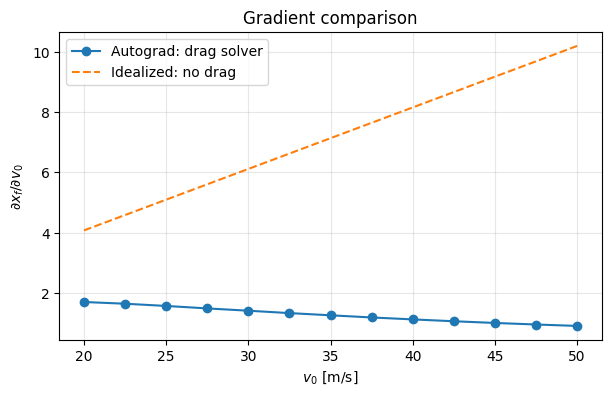

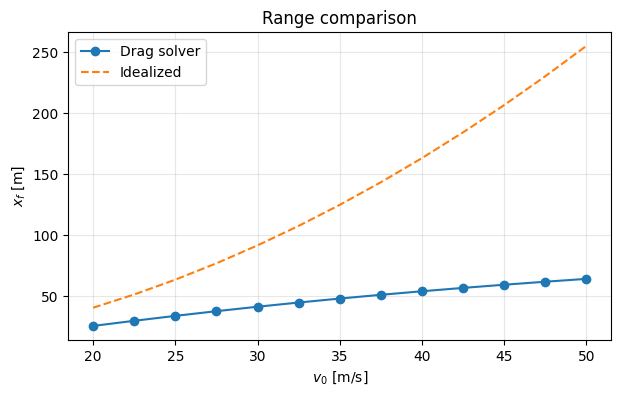

In [8]:
alpha_fixed = math.pi / 4
cd_fixed = 0.02

v_samples = torch.linspace(20.0, 50.0, 13, device=device)

# Solver-based ranges
x_drag = projectile_range_batched_vmap(v_samples, alpha_fixed, cd_fixed)

# Idealized no-drag range and gradient wrt v0: x = v0^2 sin(2a) / g
x_ideal = (v_samples**2) * math.sin(2 * alpha_fixed) / g
dx_dv_ideal = (2 * v_samples) * math.sin(2 * alpha_fixed) / g

# Autograd gradient wrt v0 for drag solver
dx_dv_drag = []
for v in v_samples:
    v_var = v.clone().detach().requires_grad_(True)
    x = projectile_range_solver(v_var, alpha_fixed, cd_fixed)
    x.backward()
    dx_dv_drag.append(v_var.grad.detach())
dx_dv_drag = torch.stack(dx_dv_drag)

# Gradient wrt alpha at v0=30
v_test = torch.tensor(30.0, device=device)
a_var = torch.tensor(alpha_fixed, device=device, requires_grad=True)
x_alpha_drag = projectile_range_solver(v_test, a_var, cd_fixed)
x_alpha_drag.backward()
dx_da_drag = a_var.grad.item()

dx_da_ideal = (2 * v_test.item()**2 * math.cos(2 * alpha_fixed)) / g

print('Gradient wrt alpha at v0=30, alpha=pi/4')
print(f'  Drag solver autograd: {dx_da_drag:.6f}')
print(f'  Idealized closed-form: {dx_da_ideal:.6f}')

plt.figure(figsize=(7, 4))
plt.plot(v_samples.cpu(), dx_dv_drag.cpu(), 'o-', label='Autograd: drag solver')
plt.plot(v_samples.cpu(), dx_dv_ideal.cpu(), '--', label='Idealized: no drag')
plt.xlabel('$v_0$ [m/s]')
plt.ylabel('$\\partial x_f / \\partial v_0$')
plt.title('Gradient comparison')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(v_samples.cpu(), x_drag.detach().cpu(), 'o-', label='Drag solver')
plt.plot(v_samples.cpu(), x_ideal.cpu(), '--', label='Idealized')
plt.xlabel('$v_0$ [m/s]')
plt.ylabel('$x_f$ [m]')
plt.title('Range comparison')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Part (3): Gradient-based optimization from different initial guesses

Target range from true v0=35.0: 48.267 m
Optimizing v0: 100%|██████████| 750/750 [03:39<00:00,  3.42it/s, init=47.0, loss=4.330e-10]
Optimization results (optimize v0):
  init= 22.0 -> v0*=35.0000, x_f= 48.2667
  init= 30.0 -> v0*=35.0000, x_f= 48.2668
  init= 47.0 -> v0*=35.0000, x_f= 48.2668


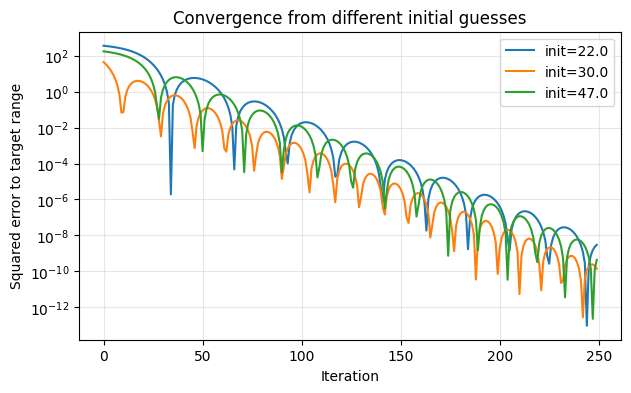

In [10]:
import sys

def inv_sigmoid(p):
    p = min(max(p, 1e-6), 1 - 1e-6)
    return math.log(p / (1 - p))

true_v0 = 35.0
target_x = projectile_range_solver(true_v0, alpha_fixed, cd_fixed).detach()
print(f'Target range from true v0={true_v0:.1f}: {target_x.item():.3f} m')

initial_guesses = [22.0, 30.0, 47.0]
results = []

total_steps = len(initial_guesses) * 250
with tqdm(total=total_steps, desc='Optimizing v0', file=sys.stdout, mininterval=0.2) as pbar:
    for init in initial_guesses:
        p0 = (init - 20.0) / 30.0
        raw = torch.tensor(inv_sigmoid(p0), device=device, requires_grad=True)
        opt = torch.optim.Adam([raw], lr=0.08)

        history = []
        for step in range(250):
            v_est = 20.0 + 30.0 * torch.sigmoid(raw)
            x_est = projectile_range_solver(v_est, alpha_fixed, cd_fixed)
            loss = (x_est - target_x).pow(2)

            opt.zero_grad()
            loss.backward()
            opt.step()

            history.append((v_est.detach().item(), loss.detach().item()))
            pbar.update(1)
            pbar.set_postfix(init=f'{init:.1f}', loss=f'{loss.item():.3e}')

            if (step + 1) % 50 == 0:
                print(f'  init={init:.1f} step={step + 1:3d}/250 loss={loss.item():.3e}', flush=True)

        v_final = 20.0 + 30.0 * torch.sigmoid(raw.detach())
        x_final = projectile_range_solver(v_final, alpha_fixed, cd_fixed).detach()
        results.append((init, v_final.item(), x_final.item(), history))

print('Optimization results (optimize v0):')
for init, v_final, x_final, _ in results:
    print(f'  init={init:5.1f} -> v0*={v_final:7.4f}, x_f={x_final:8.4f}')

plt.figure(figsize=(7, 4))
for init, _, _, history in results:
    losses = [h[1] for h in history]
    plt.plot(losses, label=f'init={init:.1f}')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Squared error to target range')
plt.title('Convergence from different initial guesses')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Part (4): Neural network inverse model $x_f \mapsto v_0$

Training inverse net: 100%|██████████| 160/160 [04:50<00:00,  1.81s/it]

Final training loss: 0.188201


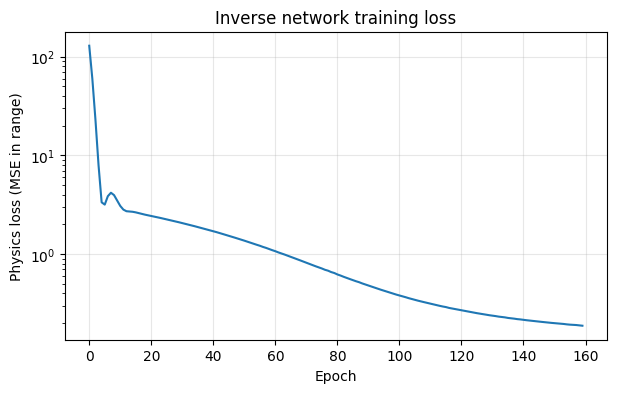

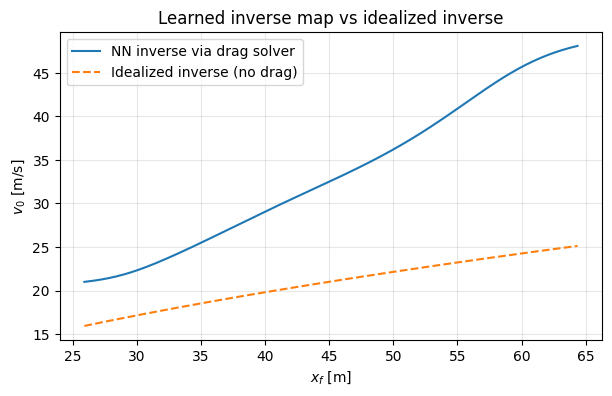

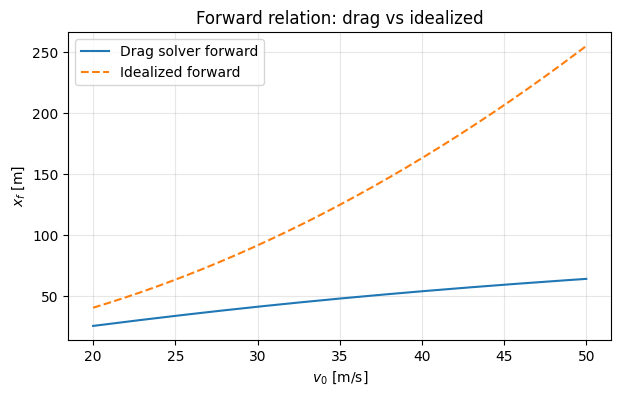

In [12]:
# Dataset generated by forward drag solver
n_train = 600
v_train = 20.0 + 30.0 * torch.rand(n_train, device=device)
with torch.no_grad():
    x_train = projectile_range_batched_vmap(v_train, alpha_fixed, cd_fixed)

x_mean = x_train.mean()
x_std = x_train.std() + 1e-12

class InverseNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(1, 32),
            torch.nn.Tanh(),
            torch.nn.Linear(32, 32),
            torch.nn.Tanh(),
            torch.nn.Linear(32, 1),
        )

    def forward(self, x):
        z = self.net(x)
        return 20.0 + 30.0 * torch.sigmoid(z)


model = InverseNet().to(device)
optim = torch.optim.Adam(model.parameters(), lr=2e-3)

batch_size = 128
epochs = 160
loss_hist = []

for _ in tqdm(range(epochs), desc='Training inverse net', leave=True):
    perm = torch.randperm(n_train, device=device)
    epoch_loss = 0.0

    for i in range(0, n_train, batch_size):
        idx = perm[i:i + batch_size]
        xb = x_train[idx]

        x_in = ((xb - x_mean) / x_std).unsqueeze(1)
        v_hat = model(x_in).squeeze(1)

        # Physics loss: backpropagate through the differentiable solver
        x_hat = projectile_range_batched_vmap(v_hat, alpha_fixed, cd_fixed)
        loss = torch.mean((x_hat - xb) ** 2)

        optim.zero_grad()
        loss.backward()
        optim.step()

        epoch_loss += loss.item() * idx.numel()

    loss_hist.append(epoch_loss / n_train)

print(f'Final training loss: {loss_hist[-1]:.6f}')

# Evaluate inverse map against idealized inverse from x = v0^2 sin(2a)/g
v_grid = torch.linspace(20.0, 50.0, 200, device=device)
with torch.no_grad():
    x_drag_grid = projectile_range_batched_vmap(v_grid, alpha_fixed, cd_fixed)

x_min, x_max = x_drag_grid.min().item(), x_drag_grid.max().item()
x_eval = torch.linspace(x_min, x_max, 200, device=device)

with torch.no_grad():
    x_in_eval = ((x_eval - x_mean) / x_std).unsqueeze(1)
    v_nn = model(x_in_eval).squeeze(1)

# alpha=pi/4 -> sin(2alpha)=1
v_ideal_inv = torch.sqrt(torch.clamp(x_eval * g, min=0.0))

plt.figure(figsize=(7, 4))
plt.plot(loss_hist)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Physics loss (MSE in range)')
plt.title('Inverse network training loss')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(x_eval.cpu(), v_nn.cpu(), label='NN inverse via drag solver')
plt.plot(x_eval.cpu(), v_ideal_inv.cpu(), '--', label='Idealized inverse (no drag)')
plt.xlabel('$x_f$ [m]')
plt.ylabel('$v_0$ [m/s]')
plt.title('Learned inverse map vs idealized inverse')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Also compare forward curves
with torch.no_grad():
    x_from_nn = projectile_range_batched_vmap(v_nn, alpha_fixed, cd_fixed)
x_ideal_forward = (v_grid**2) / g

plt.figure(figsize=(7, 4))
plt.plot(v_grid.cpu(), x_drag_grid.cpu(), label='Drag solver forward')
plt.plot(v_grid.cpu(), x_ideal_forward.cpu(), '--', label='Idealized forward')
plt.xlabel('$v_0$ [m/s]')
plt.ylabel('$x_f$ [m]')
plt.title('Forward relation: drag vs idealized')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Part (4) diagnostic: inverse consistency check

Inverse consistency RMSE: 0.4504 m
Inverse consistency MAE : 0.3051 m
Inverse consistency MaxE: 1.7684 m


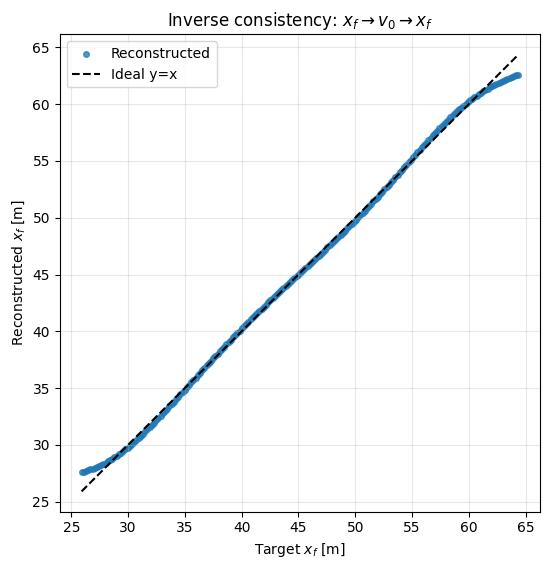

In [14]:
# Consistency check: x -> v_hat(x) -> x_reconstructed
with torch.no_grad():
    x_reconstructed = projectile_range_batched_vmap(v_nn, alpha_fixed, cd_fixed)

err = x_reconstructed - x_eval
rmse = torch.sqrt(torch.mean(err**2)).item()
mae = torch.mean(torch.abs(err)).item()
max_abs = torch.max(torch.abs(err)).item()

print(f'Inverse consistency RMSE: {rmse:.4f} m')
print(f'Inverse consistency MAE : {mae:.4f} m')
print(f'Inverse consistency MaxE: {max_abs:.4f} m')

plt.figure(figsize=(6.2, 6.2))
plt.scatter(x_eval.cpu(), x_reconstructed.cpu(), s=16, alpha=0.75, label='Reconstructed')
lims = [x_eval.min().item(), x_eval.max().item()]
plt.plot(lims, lims, 'k--', label='Ideal y=x')
plt.xlabel('Target $x_f$ [m]')
plt.ylabel('Reconstructed $x_f$ [m]')
plt.title(r'Inverse consistency: $x_f \rightarrow v_0 \rightarrow x_f$')
plt.grid(alpha=0.3)
plt.legend()
plt.axis('equal')
plt.show()

## Results
- The differentiable drag solver produces a smooth mapping from $(v_0,\alpha,c_d)$ to final range $x_f$.
- Compared to the idealized no-drag model, both $x_f$ and $\partial x_f/\partial v_0$ are lower in the drag model, and the gap grows with larger $v_0$.
- At $\alpha=\pi/4$, the idealized model gives $\partial x_f/\partial \alpha=0$, while the drag-aware solver gives a nonzero value due to drag-induced asymmetry.
- Gradient-based optimization for $v_0$ converges from multiple initial guesses to the same target solution; the loss curves show damped oscillations (optimizer overshoot/correction behavior) with a decreasing envelope.
- The inverse neural network trained through solver backprop learns a drag-consistent inverse map; compared with the idealized inverse, it requires larger $v_0$ for the same $x_f$ because drag shortens range.
- In this run, the inverse-model training reached a final physics loss of approximately $1.88\times10^{-1}$ after 160 epochs.
- The inverse-consistency check ($x_f\rightarrow\hat v_0\rightarrow\hat x_f$) confirms that reconstructed ranges stay close to targets, supporting that the learned inverse is physically consistent with the drag solver.

## Discussion
The differences from the idealized expression come from two effects: (i) physical modeling (quadratic drag removes kinetic energy and changes optimal angle behavior), and (ii) numerical approximation (time discretization and impact interpolation). In this notebook, the physical effect dominates: drag compresses the range curve and reduces sensitivity to speed compared to the no-drag formula.

Using autograd through the solver enables direct parameter fitting and inverse learning without deriving custom adjoints. The optimization runs show that, for this one-parameter target-matching problem, convergence is robust to initialization. The inverse network also trains reliably when the loss is defined through the differentiable simulator, demonstrating a practical physics-informed learning setup.

Effectively, this exercise builds one differentiable computational pipeline: $(v_0,\alpha,c_d)\rightarrow x_f$ via a simulator, then uses gradients from that simulator for both parameter optimization and training an inverse model. In other words, instead of fitting only to formulas, we fit through physics directly and verify that the learned inverse remains consistent when reinserted into the same physical model.

# Exercise 2: Jacobian Calculation Differentiating Through Solvers

## Problem Statement
Given
$$
\mathbf{f}(x_1,x_2)=
\begin{bmatrix}
2x_1^3+5x_2^2\\
3x_1^5+2x_2^2
\end{bmatrix},
\quad
J(\mathbf{x})=
\begin{bmatrix}
6x_1^2 & 10x_2\\
15x_1^4 & 4x_2
\end{bmatrix},
$$
we compute the Jacobian with automatic differentiation using (1) backward mode and (2) forward mode, and compare with the analytical Jacobian. Then we generalize to high-dimensional
$$
g_i(\mathbf{x})=x_i^3+\sum_{j=1}^n x_j,
\quad
J_{ij}=3x_i^2\delta_{ij}+1.
$$

## Approach / Method
- Define $\mathbf{f}$ and analytical Jacobian $J$.
- Compute Jacobian by backward AD with `torch.autograd.functional.jacobian`.
- Compute Jacobian by forward AD using `torch.func.jvp` with basis tangent vectors.
- Generalize to $\mathbf{g}:\mathbb{R}^n\to\mathbb{R}^n$ and compare AD Jacobian with the analytical closed form for multiple $n$.

## Part (1): Jacobian via backward-mode AD

In [15]:
def f_vec(x):
    x1, x2 = x[0], x[1]
    return torch.stack([
        2.0 * x1**3 + 5.0 * x2**2,
        3.0 * x1**5 + 2.0 * x2**2,
    ])


def jacobian_f_analytic(x):
    x1, x2 = x[0], x[1]
    return torch.stack([
        torch.stack([6.0 * x1**2, 10.0 * x2]),
        torch.stack([15.0 * x1**4, 4.0 * x2]),
    ])


x0 = torch.tensor([1.2, -0.7], dtype=torch.get_default_dtype(), device=device, requires_grad=True)

J_backward = torch.autograd.functional.jacobian(f_vec, x0)
J_true = jacobian_f_analytic(x0.detach())

print('x0 =', x0.detach().cpu().numpy())
print('\nAnalytical Jacobian:')
print(J_true.detach().cpu().numpy())
print('\nBackward AD Jacobian:')
print(J_backward.detach().cpu().numpy())
print('\nMax abs error:', torch.max(torch.abs(J_backward - J_true)).item())

x0 = [ 1.2 -0.7]

Analytical Jacobian:
[[ 8.64  -7.   ]
 [31.104 -2.8  ]]

Backward AD Jacobian:
[[ 8.64  -7.   ]
 [31.104 -2.8  ]]

Max abs error: 3.552713678800501e-15


## Part (2): Jacobian via forward-mode AD (`torch.func.jvp`)

In [16]:
def jacobian_forward_jvp(func, x):
    n = x.numel()
    basis = torch.eye(n, dtype=x.dtype, device=x.device)
    cols = []
    for j in range(n):
        _, jvp_out = torch.func.jvp(func, (x,), (basis[j],))
        cols.append(jvp_out)
    return torch.stack(cols, dim=1)


x0_forward = x0.detach().clone()
J_forward = jacobian_forward_jvp(f_vec, x0_forward)

print('Forward AD Jacobian (via jvp):')
print(J_forward.detach().cpu().numpy())
print('\nMax abs error vs analytical:', torch.max(torch.abs(J_forward - J_true)).item())
print('Max abs diff vs backward AD:', torch.max(torch.abs(J_forward - J_backward.detach())).item())

Forward AD Jacobian (via jvp):
[[ 8.64  -7.   ]
 [31.104 -2.8  ]]

Max abs error vs analytical: 3.552713678800501e-15
Max abs diff vs backward AD: 0.0


## Part (3): High-dimensional generalization for $\mathbf{g}:\mathbb{R}^n\rightarrow\mathbb{R}^n$

In [17]:
def g_vec(x):
    s = torch.sum(x)
    return x**3 + s


def jacobian_g_analytic(x):
    n = x.numel()
    J = torch.ones((n, n), dtype=x.dtype, device=x.device)
    idx = torch.arange(n, device=x.device)
    J[idx, idx] += 3.0 * x**2
    return J


n_values = [3, 6, 12]
print('High-dimensional Jacobian checks:')
for n in n_values:
    x_n = torch.linspace(-1.0, 1.0, n, dtype=torch.get_default_dtype(), device=device)

    Jn_forward = jacobian_forward_jvp(g_vec, x_n)
    Jn_true = jacobian_g_analytic(x_n)
    err_forward = torch.max(torch.abs(Jn_forward - Jn_true)).item()

    Jn_backward = torch.autograd.functional.jacobian(g_vec, x_n)
    err_backward = torch.max(torch.abs(Jn_backward - Jn_true)).item()

    print(f'  n={n:2d} | max error forward={err_forward:.3e} | max error backward={err_backward:.3e}')

High-dimensional Jacobian checks:
  n= 3 | max error forward=0.000e+00 | max error backward=0.000e+00
  n= 6 | max error forward=0.000e+00 | max error backward=0.000e+00
  n=12 | max error forward=0.000e+00 | max error backward=0.000e+00


## Part (4): Runtime comparison (backward vs forward Jacobian)

Timing Jacobian computation for g: R^n -> R^n
(average over repeats, milliseconds)
  n= 10 | backward=   0.810 ms | forward=   1.588 ms
  n= 20 | backward=   1.390 ms | forward=   2.090 ms
  n= 40 | backward=   1.662 ms | forward=   3.038 ms
  n= 80 | backward=   3.055 ms | forward=   5.846 ms
  n=160 | backward=   6.238 ms | forward=  11.636 ms
  n=320 | backward=  12.401 ms | forward=  23.460 ms
  n=640 | backward=  25.752 ms | forward=  54.385 ms
  n=1280 | backward=  55.595 ms | forward= 101.860 ms
  n=2560 | backward= 118.613 ms | forward= 293.367 ms
  n=5120 | backward= 322.837 ms | forward=1585.289 ms
  n=10240 | backward= 709.998 ms | forward=3254.948 ms


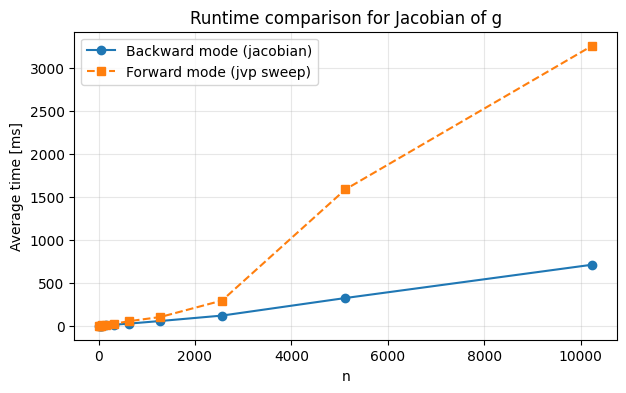

In [19]:
import time

n_timing = [10, 20, 40, 80, 160, 320, 640, 1280, 2560, 5120, 10240]
repeats = 4

backward_times_ms = []
forward_times_ms = []

print('Timing Jacobian computation for g: R^n -> R^n')
print('(average over repeats, milliseconds)')

for n in n_timing:
    x_n = torch.linspace(-1.0, 1.0, n, dtype=torch.get_default_dtype(), device=device)

    # Warm-up
    _ = torch.autograd.functional.jacobian(g_vec, x_n)
    _ = jacobian_forward_jvp(g_vec, x_n)

    t_back = 0.0
    for _ in range(repeats):
        t0 = time.perf_counter()
        _ = torch.autograd.functional.jacobian(g_vec, x_n)
        t_back += (time.perf_counter() - t0)

    t_forw = 0.0
    for _ in range(repeats):
        t0 = time.perf_counter()
        _ = jacobian_forward_jvp(g_vec, x_n)
        t_forw += (time.perf_counter() - t0)

    backward_ms = 1000.0 * t_back / repeats
    forward_ms = 1000.0 * t_forw / repeats

    backward_times_ms.append(backward_ms)
    forward_times_ms.append(forward_ms)

    print(f'  n={n:3d} | backward={backward_ms:8.3f} ms | forward={forward_ms:8.3f} ms')

plt.figure(figsize=(7, 4))
plt.plot(n_timing, backward_times_ms, 'o-', label='Backward mode (jacobian)')
plt.plot(n_timing, forward_times_ms, 's--', label='Forward mode (jvp sweep)')
plt.xlabel('n')
plt.ylabel('Average time [ms]')
plt.title('Runtime comparison for Jacobian of g')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Results
- For the 2D function $\mathbf{f}$, backward-mode AD Jacobian matches the analytical Jacobian up to numerical precision.
- Forward-mode AD computed with `torch.func.jvp` also matches the analytical Jacobian and agrees with backward-mode AD.
- For the generalized $\mathbf{g}:\mathbb{R}^n\rightarrow\mathbb{R}^n$, both forward and backward AD Jacobians match the analytical form for different $n$ values.

## Discussion
This exercise demonstrates how Jacobians can be obtained directly from differentiable programs without manual derivative coding. Backward mode is typically efficient when outputs are fewer than inputs, while forward mode is often attractive when directional derivatives are needed or when the input dimension is modest. For square systems ($n\times n$), both approaches recover the same Jacobian and provide a practical route for sensitivity analysis in solver-based models.